## `dta setup`

In [11]:
"""IMPORT EVERYTHING.. """
# Data manipulation
import pandas as pd
import numpy as np

# # Quantitative analysis / indicators
import talib
import backtrader as bt
# import vectorbt as vbt


# # Machine learning / statistics
# import scipy
# from sklearn.model_selection import train_test_split
# from sklearn.linear_model import LinearRegression

# # Visualization
# import matplotlib.pyplot as plt
# import seaborn as sns
# import mplfinance as mpf


from resampler import OHLCVResampler
# # Jupyter Notebook magic for inline plots
# %matplotlib inline

# import pandas_ta as ta



In [12]:
"""Load Source OHLCV dta"""

df = pd.read_parquet("../Src/XAUUSDc_M1.parquet", engine="pyarrow")

In [13]:
resampler = OHLCVResampler(default_agg='last')

ohlcv = {}

ohlcv['1M'] = resampler.resample(df,'1min').ffill()
ohlcv['5M'] = resampler.resample(df,'5min').ffill()
ohlcv['15M'] = resampler.resample(df,'15min').ffill()

In [14]:
for key, df_tf in ohlcv.items():
    print(f"\n=== {key} === {df_tf.shape}")


=== 1M === (525533, 5)

=== 5M === (105107, 5)

=== 15M === (35036, 5)


## `b ktst`

In [15]:
import pandas as pd
import pandas_ta as ta
import mplfinance as mpf
import numpy as np
import matplotlib.pyplot as plt

# Enable matplotlib in Jupyter
%matplotlib inline

# --------------------------
# 1️⃣ Squeeze indicator
# --------------------------
def jambura(df, bb_length=11, bb_mult=1.7, kc_length=21, kc_mult=1.5):
    df_out = df.copy()
    close = df_out['close']
    high = df_out['high']
    low = df_out['low']

    # Bollinger Bands
    bb = ta.bbands(close, length=bb_length, std=bb_mult)
    upper_bb = bb.iloc[:, 2]  # Upper band
    lower_bb = bb.iloc[:, 0]  # Lower band

    # Keltner Channel
    kc = ta.kc(high, low, close, length=kc_length, scalar=kc_mult)
    upper_kc = kc.iloc[:, 2]
    lower_kc = kc.iloc[:, 0]

    # Squeeze detection
    sqz_on = (lower_bb > lower_kc) & (upper_bb < upper_kc)
    no_sqz = (lower_bb < lower_kc) & (upper_bb > upper_kc)
    sqz_off = ~sqz_on & ~no_sqz

    # Signal colors
    signal_colors = np.empty(len(df_out), dtype=object)
    signal_colors[sqz_on] = 'black'
    signal_colors[no_sqz] = 'blue'
    signal_colors[sqz_off] = 'gray'

    df_out['sqz_on'] = sqz_on
    df_out['no_sqz'] = no_sqz
    df_out['sqz_off'] = sqz_off
    df_out['signal_color'] = signal_colors

    return df_out

In [16]:

# --------------------------------+
# 3️⃣ Prepare data and indicators |
# ------------------------------ +
df = ohlcv['1M'][:500].copy()

# MACD
macd = ta.macd(df['close'])

df['MACD'] = macd['MACD_12_26_9']
df['MACD_signal'] = macd['MACDs_12_26_9']
df['MACD_hist'] = macd['MACDh_12_26_9']

df['MACD_Cross_up'] = ta.cross(df['MACD'],df['MACD_signal'])
df['MACD_Cross_dn'] = ta.cross(df['MACD_signal'],df['MACD'])

cross_up = df['MACD'].where(df['MACD_Cross_up'] != 0)
cross_dn = df['MACD'].where(df['MACD_Cross_dn'] != 0)

# RSI
df['RSI'] = ta.rsi(df['close'], length=14)
df = jambura(df)


df['signal'] = (df['MACD_Cross_dn'] == 1) & (df['signal_color'] == 'gray')
# df['signal'] = (df['MACD_Cross_dn'] == 1) & (df['signal_color'] == 'gray') & (df['RSI'] > 70 )

In [17]:
vline_dates = df.index[df['signal']]
# vline_dates

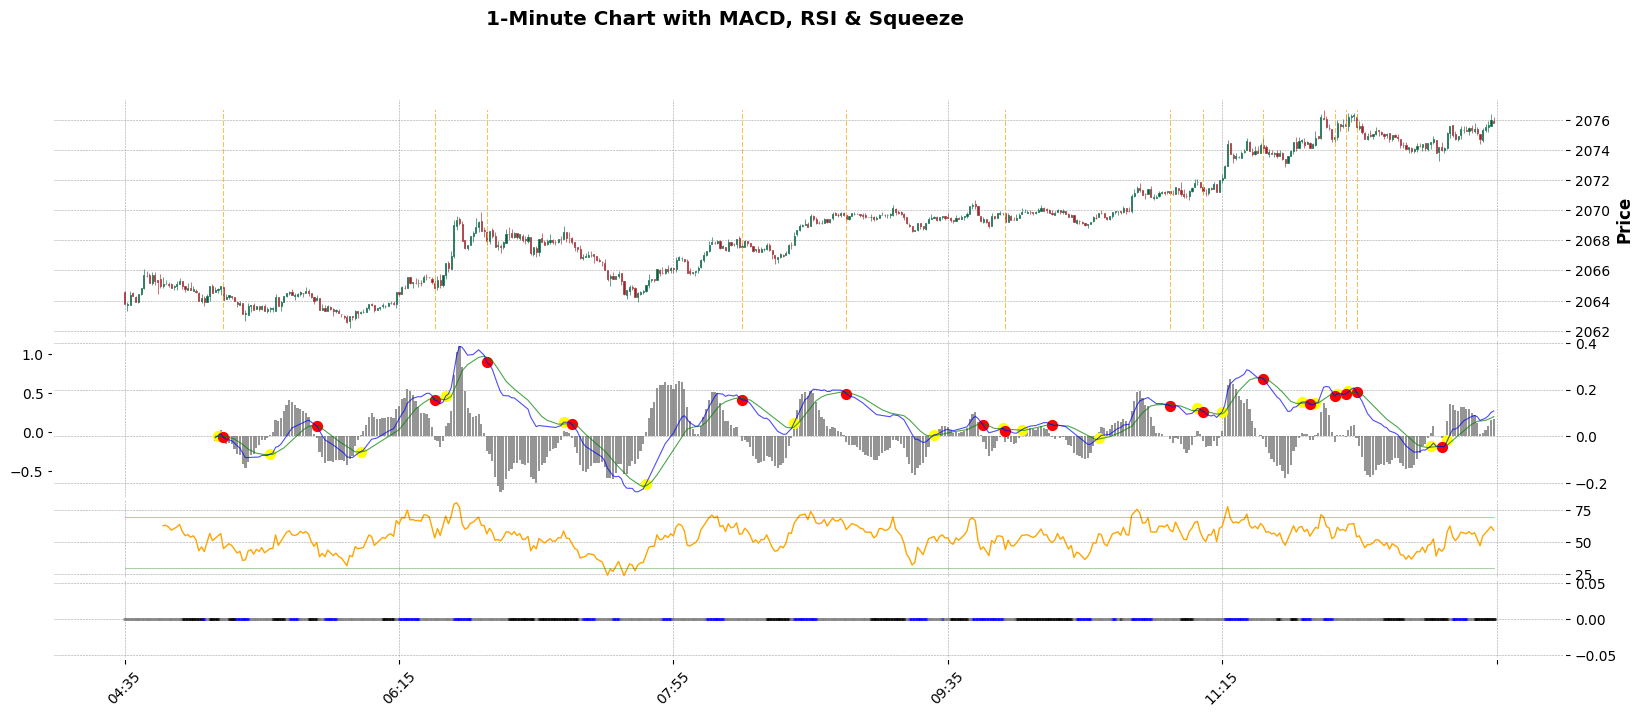

In [18]:
# --------------------------
# 4️⃣ Prepare addplots
# --------------------------
add_plots = [
    # MACD panel
    mpf.make_addplot(df['MACD_hist'], panel=1, type='bar', color='dimgray', alpha=0.7),
    mpf.make_addplot(df['MACD_signal'], panel=1, type='line', color='green', alpha=0.7, width=0.8),
    mpf.make_addplot(df['MACD'], panel=1, type='line', color='blue', alpha=0.7, width=0.8),
    mpf.make_addplot(cross_up, panel=1, type='scatter', markersize=50, marker='o', color='yellow'),
    mpf.make_addplot(cross_dn, panel=1, type='scatter', markersize=50, marker='o', color='red'),
    # RSI panel
    mpf.make_addplot(df['RSI'], panel=2, type='line', color='orange', width=1),
    mpf.make_addplot(pd.Series(70, index=df.index), panel=2, type='line', color='red', width=0.5, alpha=0.5),
    mpf.make_addplot(pd.Series(30, index=df.index), panel=2, type='line', color='green', width=0.5, alpha=0.5),
]

# Squeeze scatter on panel 3
squeeze_level = pd.Series(0, index=df.index)
for color in ['black', 'blue', 'gray']:
    mask = df['signal_color'] == color
    if mask.any():
        s = squeeze_level.copy()
        s[~mask] = np.nan
        add_plots.append(mpf.make_addplot(s, panel=3, type='scatter', marker='_',
                                          color=color, markersize=12, alpha=0.9))

# --------------------------
# 5️⃣ Plot
# --------------------------
mpf.plot(df,
        type='candle',
        style='charles',
        title='1-Minute Chart with MACD, RSI & Squeeze',
        addplot=add_plots,
        panel_ratios=(3, 2, 1, 1),
        figsize=(21, 8),
        vlines = {
        'vlines': vline_dates.to_list(),
        'colors': 'orange',
        'linewidths': 0.9,
        'linestyle': '--',
        'alpha': 0.7
        },
        warn_too_much_data=len(df))

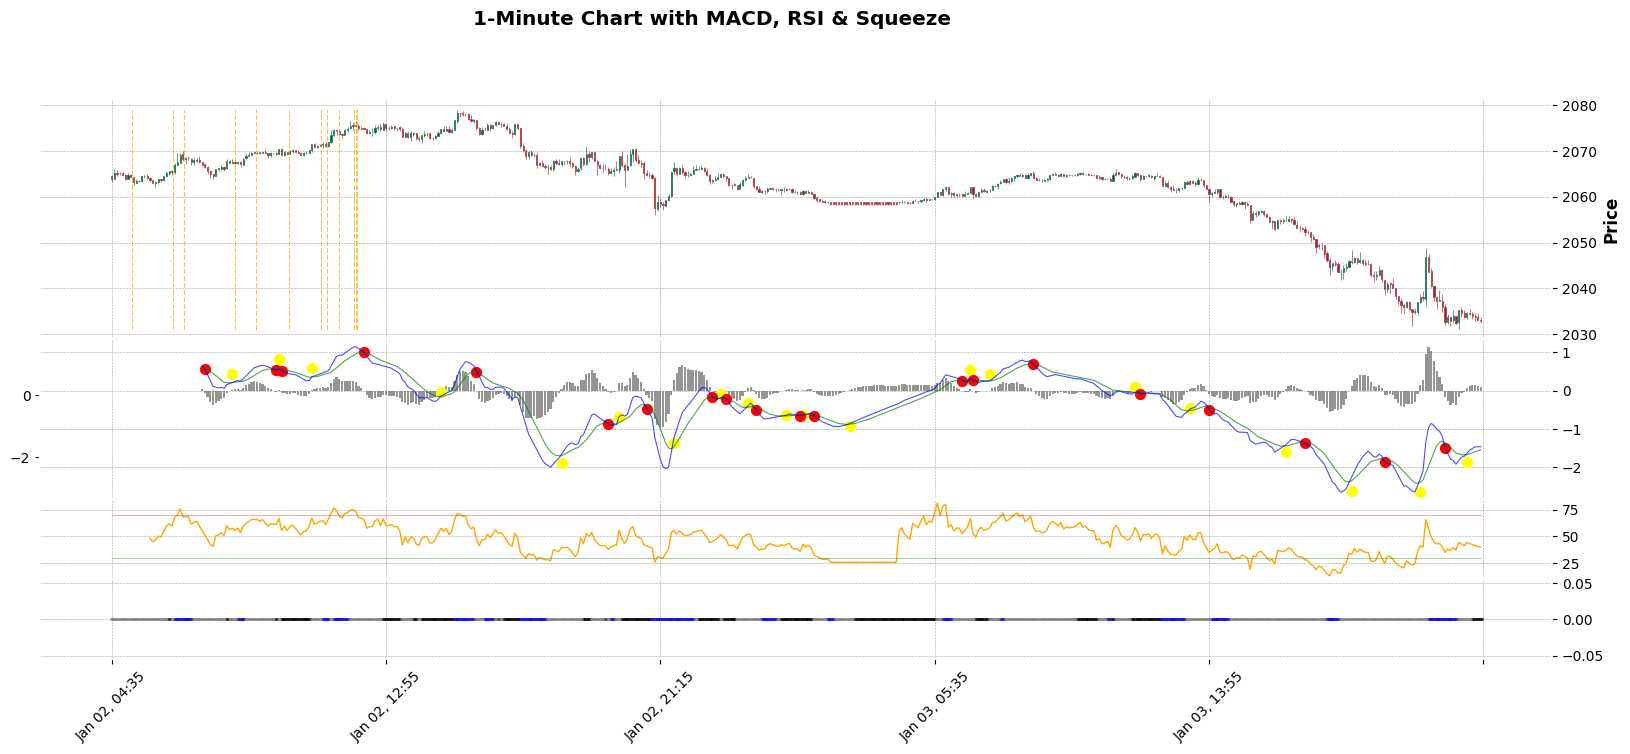

In [20]:

# --------------------------------+
# 3️⃣ Prepare data and indicators |
# ------------------------------ +
df = ohlcv['5M'][:500].copy()

# MACD
macd = ta.macd(df['close'])

df['MACD'] = macd['MACD_12_26_9']
df['MACD_signal'] = macd['MACDs_12_26_9']
df['MACD_hist'] = macd['MACDh_12_26_9']

df['MACD_Cross_up'] = ta.cross(df['MACD'],df['MACD_signal'])
df['MACD_Cross_dn'] = ta.cross(df['MACD_signal'],df['MACD'])

cross_up = df['MACD'].where(df['MACD_Cross_up'] != 0)
cross_dn = df['MACD'].where(df['MACD_Cross_dn'] != 0)

# RSI
df['RSI'] = ta.rsi(df['close'], length=14)
df = jambura(df)


df['signal'] = (df['MACD_Cross_dn'] == 1) & (df['signal_color'] == 'gray')
# df['signal'] = (df['MACD_Cross_dn'] == 1) & (df['signal_color'] == 'gray') & (df['RSI'] > 70 )




# --------------------------
# 4️⃣ Prepare addplots
# --------------------------
add_plots = [
    # MACD panel
    mpf.make_addplot(df['MACD_hist'], panel=1, type='bar', color='dimgray', alpha=0.7),
    mpf.make_addplot(df['MACD_signal'], panel=1, type='line', color='green', alpha=0.7, width=0.8),
    mpf.make_addplot(df['MACD'], panel=1, type='line', color='blue', alpha=0.7, width=0.8),
    mpf.make_addplot(cross_up, panel=1, type='scatter', markersize=50, marker='o', color='yellow'),
    mpf.make_addplot(cross_dn, panel=1, type='scatter', markersize=50, marker='o', color='red'),
    # RSI panel
    mpf.make_addplot(df['RSI'], panel=2, type='line', color='orange', width=1),
    mpf.make_addplot(pd.Series(70, index=df.index), panel=2, type='line', color='red', width=0.5, alpha=0.5),
    mpf.make_addplot(pd.Series(30, index=df.index), panel=2, type='line', color='green', width=0.5, alpha=0.5),
]

# Squeeze scatter on panel 3
squeeze_level = pd.Series(0, index=df.index)
for color in ['black', 'blue', 'gray']:
    mask = df['signal_color'] == color
    if mask.any():
        s = squeeze_level.copy()
        s[~mask] = np.nan
        add_plots.append(mpf.make_addplot(s, panel=3, type='scatter', marker='_',
                                          color=color, markersize=12, alpha=0.9))

# --------------------------
# 5️⃣ Plot
# --------------------------
mpf.plot(df,
        type='candle',
        style='charles',
        title='1-Minute Chart with MACD, RSI & Squeeze',
        addplot=add_plots,
        panel_ratios=(3, 2, 1, 1),
        figsize=(21, 8),
        vlines = {
        'vlines': vline_dates.to_list(),
        'colors': 'orange',
        'linewidths': 0.9,
        'linestyle': '--',
        'alpha': 0.7
        },
        warn_too_much_data=len(df))